<a href="https://colab.research.google.com/github/ShimleenNawal/Amazon-Prime-TV-Shows-and-Movies-EDA/blob/main/Amazon_Prime_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name - Exploratory Data Analysis of Amazon Prime Videos Content Library**



##### **Project Type**    - EDA
##### **Contribution**    - Individual


## **Project Summary -**

The goal of the project is to perform EDA on the Amazon Prime Video dataset to better understand the content catalog of TV shows and movies on the platform. The analysis reveals insights, trends, and patterns related to content type, genre distribution, release years, and regional availability.

**Key Steps:**

1. **Data Collection and Cleaning:**
- Merged two datasets (`titles.csv` and `credits.csv`) using a common key (`id`)
- Performed initial data inspection to understand structure and features
- Cleaned the dataset:
  - Removed duplicate records
  - Handled missing values (median for numerical, "Unknown" for categorical)
- Identified numerical and categorical columns for analysis

2. **Data Visualization:**

- Conducted **Univariate Analysis**:
  - Histograms to study distributions
  - Boxplots to detect outliers
  - Count plots and pie charts for categorical variables

- Conducted **Bivariate Analysis**:
  - Scatter plots to explore relationships
  - Heatmap to analyze correlations
  - Bar plots and boxplots for category comparisons

- Used advanced visualizations:
  - Pairplot for multivariable relationships
  - Violin plots for distribution comparison
  - Regression plots for trend analysis

- Analyzed trends over time (e.g., release year patterns)
- Generated insights from each visualization

- Identified key patterns:
  - Skewed distributions in numerical features
  - Dominant categories in categorical variables
  - Moderate correlations between certain features

3. **Insights** :

- Amazon Prime Video has more movies than TV shows.
Drama and comedy are the most common genres.

- Movie runtimes have slightly decreased over the years, while TV shows have more seasons.

- Older titles tend to have higher ratings than newer releases.

- The United States is the primary content producer, followed by India and the United Kingdom.


This EDA provides valuable information for understanding the landscape of Amazon Prime Video's content. Content creators, platform strategists, and viewers can benefit from this analysis for making informed decisions. Future research could focus on specific genres, regions, or content types for deeper insights.

# **GitHub Link -**

https://github.com/ShimleenNawal/Amazon-Prime-TV-Shows-and-Movies-EDA

# **Problem Statement**


This dataset was created to analyze all shows available on Amazon Prime Video, allowing us to extract valuable insights such as:

**Content Diversity :** Extracting the dominant genres and categories on Amazon Prime is essential for strategic content investment.

**Regional Availability :** Increasing content distribution across different regions and catering to region-based preferred content helps promote subscription growth.


**Trends Over Time :** The entertainment industry evolves continuously. It is crucial to analyze how Amazon Prime's content library has changed to cater to viewer preferences and market trends.

**IMDb Ratings & Popularity :** IMDb ratings and popularity scores provide valuable insights into viewer engagement and satisfaction. Analyzing these metrics enables identification of  high-performing content and potential areas for improvement.

## **Business Objective :**

The main business objective for Amazon Prime Video is to understand its existing catalogue mix across type, genre, country, and quality so it can optimize acquisition and production strategy. By analyzing historical titles, we can identify which genres, regions, and formats deliver the highest perceived quality (IMDb score) and engagement (votes), and detect gaps in the library where user demand may be underserved.

## **Data Wrangling**

In [2]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Datasets
from google.colab import drive
drive.mount('/content/drive')

titles = pd.read_csv('/content/drive/MyDrive/Amazon_Prime_EDA/titles.csv.zip')
credits = pd.read_csv('/content/drive/MyDrive/Amazon_Prime_EDA/credits.csv.zip')

Mounted at /content/drive


In [4]:
# Dataset First Look
titles.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [5]:
credits.columns

Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')

In [6]:
#Merge two datasets on common column id
data = pd.merge(titles,credits, on = 'id')

In [7]:
#print the merged data
data

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124342,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938589,Sangam Shukla,Madhav,ACTOR
124343,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938565,Vijay Thakur,Sanjay Thakur,ACTOR
124344,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,728899,Vanya Wellens,Budhiya,ACTOR
124345,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938620,Vishwa Bhanu,Gissu,ACTOR


In [8]:
# Dataset Rows & Columns count
data.shape

(124347, 19)

In [9]:
#View all the columns of dataset
data.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'person_id', 'name', 'character', 'role'],
      dtype='object')

In [10]:
# Dataset Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124347 entries, 0 to 124346
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    124347 non-null  object 
 1   title                 124347 non-null  object 
 2   type                  124347 non-null  object 
 3   description           124256 non-null  object 
 4   release_year          124347 non-null  int64  
 5   age_certification     56707 non-null   object 
 6   runtime               124347 non-null  int64  
 7   genres                124347 non-null  object 
 8   production_countries  124347 non-null  object 
 9   seasons               8153 non-null    float64
 10  imdb_id               119044 non-null  object 
 11  imdb_score            118296 non-null  float64
 12  imdb_votes            118272 non-null  float64
 13  tmdb_popularity       124332 non-null  float64
 14  tmdb_score            114082 non-null  float64
 15  

#### Handling Missing Values

In [11]:
# Missing Values/Null Values Count
data.isnull().sum()

,0
id,0
title,0
type,0
description,91
release_year,0
age_certification,67640
runtime,0
genres,0
production_countries,0
seasons,116194


In [12]:
#drop null values in description column
data.dropna(subset = ['description'], inplace = True)

In [13]:
#Mode of age_certification
data['age_certification'].mode()[0]


'R'

In [14]:
#Replace all null values of age_certification with mode
data['age_certification'].fillna(data['age_certification'].mode()[0], inplace = True)

The 'seasons' column has null values because seasons are only applicable to TV shows, not movies. Instead of removing null rows, replace them with 0.

In [15]:
#null values in seasons column to 0
data['seasons'].fillna(0, inplace = True)

'imdb_id' is unique for Movies and TV shows, so all null entries in 'imdb_id' column should be dropped.

In [16]:
data.dropna(subset = ['imdb_id'], inplace = True)

'imdb_score' denotes the rating of a Movie or TV show. So, removing null values in 'imdb_score' might lead to data loss and it's better to replace them with mean.




In [17]:
round(data['imdb_score'].mean(),1)

np.float64(6.0)

In [18]:
#null values in imdb_score to mean of imdb_score
data['imdb_score'].fillna(round(data['imdb_score'].mean(),1), inplace = True)

'imdb_votes' is the number of votes a Movie or TV show has received. Null values in 'imdb_votes' can be replaced with 0 because movie might be relatively new or might not have gained much attention.

In [19]:
data['imdb_votes'].fillna(0, inplace = True)

'tmdb_popularity' and 'tmdb_score' can be handled similarly.

In [20]:
#Mean of tmdb_popularity
round(data['tmdb_popularity'].mean(),2)

np.float64(10.32)

In [21]:
#null values in 'tmdb_popularity' column to mean
data['tmdb_popularity'].fillna(round(data['tmdb_popularity'].mean(),2), inplace =True)

In [22]:
#Mean of tmdb_score
round(data['tmdb_score'].mean(),1)

np.float64(6.0)

In [23]:
#null values in 'tmdb_score' column to mean
data['tmdb_score'].fillna(round(data['tmdb_score'].mean(),1), inplace = True)

Missing values in the 'characters' column means that character information in movie or TV show is not available in the database and should be replaced with 'unknown'.

In [24]:
data['character'].fillna('unknown', inplace = True)

In [25]:
data.isnull().sum()

,0
id,0
title,0
type,0
description,0
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,0
seasons,0


In [26]:
data.shape

(119022, 19)

# Handling Duplicate Values

In [27]:
data.duplicated().sum()

np.int64(168)

168 duplicates in dataset will be dropped to clean the data.

In [28]:
data.drop_duplicates(inplace = True)

In [29]:
data.duplicated().sum()

np.int64(0)

In [30]:
data.dtypes

,0
id,object
title,object
type,object
description,object
release_year,int64
age_certification,object
runtime,int64
genres,object
production_countries,object
seasons,float64


In [31]:
data.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id
count,118854.000000,118854.000000,118854.000000,118854.000000,1.188540e+05,118854.000000,118854.000000,1.188540e+05
mean,1995.694592,96.054453,0.153466,5.968800,2.312887e+04,10.334860,5.997704,3.976869e+05
std,28.010517,29.798646,1.006917,1.238147,8.819975e+04,40.786345,1.252196,5.549632e+05
min,1912.000000,1.000000,0.000000,1.100000,0.000000e+00,0.000164,0.800000,1.000000e+00
25%,1980.000000,83.000000,0.000000,5.200000,2.790000e+02,1.917000,5.400000,3.821300e+04
50%,2009.000000,94.000000,0.000000,6.000000,1.227000e+03,3.960000,6.000000,1.323810e+05
75%,2017.000000,109.000000,0.000000,6.800000,7.040000e+03,8.924000,6.800000,5.633935e+05
max,2022.000000,328.000000,49.000000,9.900000,1.133692e+06,1437.906000,10.000000,2.371153e+06


The dataset is now clean and ready for further analysis. The manipulations performed on given data are as follows:
1. **Data Loading and Merging** : Two datasets, titles.csv and credits.csv, were loaded and merged based on the common column 'id'.
2. **Handling Missing Values** :
- Null values in the 'description' and 'imdb_id' columns were dropped.
- Null values in 'age_certification' were replaced with the mode.
- Null values in 'seasons', 'imdb_votes', and 'character' were replaced with 0, 0, and 'unknown', respectively.
- Null values in 'imdb_score', 'tmdb_popularity', and 'tmdb_score' were replaced with their respective means.
3. **Handling Duplicates** : Duplicate rows identified and removed from the dataset.

##**Dataset Description**

The dataset is related to movies and TV shows available on Amazon Prime Video. It's formed by merging two datasets: titles.csv and credits.csv.

**title.csv** dataset contains information about movies and TV shows available on Amazon Prime Video. Each row represents a single title.

**credits.csv** dataset contains information about the people involved in the production of the titles (actors, directors, etc.). Each row represents a person's involvement in a specific title.

## **Dataset Columns :**


**id**: Unique identifier for each title (movie or TV show)

**title**: Title of the movie or TV show

**type**: Whether it's a TV show or a movie

**description**: A brief description of the title

**release_year**: The year the title was released

**age_certification**: Age rating or certification (e.g., PG-13, TV-MA)

**runtime**: Duration of the movie or TV show in minutes

**genres**: List of genres associated with the title (e.g., ['horror', 'drama'])

**production_countries**: List of countries where the title was produced

**seasons**: Number of seasons (for TV shows only)

**imdb_id**: IMDb identifier for the title

**imdb_score**: IMDb rating of the title

**imdb_votes**: Number of votes the title received on IMDb

**tmdb_popularity**: Popularity score from TMDb (The Movie Database)

**tmdb_score**: Rating score from TMDb

**person_id**: Unique identifier for a person involved in the production (actor, director, etc.)

**name**: Name of the person (actor, director, etc.)

**character**: The character played by the person (for actors)

**role**: The role of the person in the production (e.g., 'ACTOR', 'DIRECTOR')

#**Data Visualization:**  

Data visualization is the graphical representation of information and data. By using visual elements like charts, graphs, and maps, data visualization tools provide an accessible way to see and understand trends, outliers, and patterns in data.

##**Univariate Analysis**

#### Histogram

Histograms represents the distribution of numerical variable. They provide a visual way to see the shape of data's distribution.

In [53]:
def clean_plot():
    sns.despine()
    plt.grid(False)

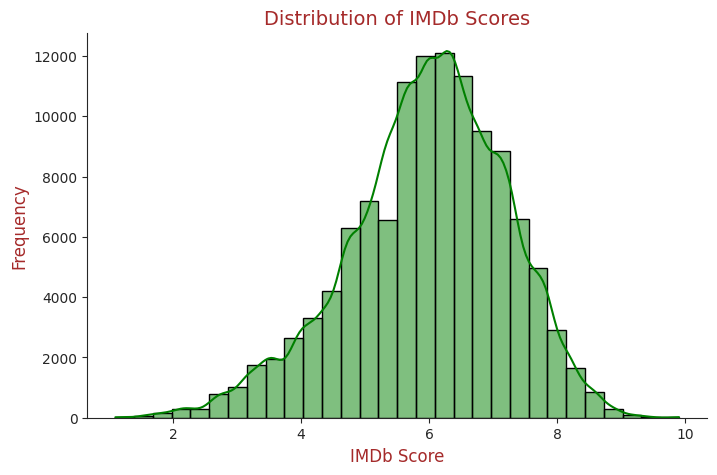

In [57]:
# 1 Histogram of imdb_score
plt.figure(figsize=(8,5))
sns.histplot(data['imdb_score'], bins=30, color = 'green', edgecolor='black', kde = True)
plt.title("Distribution of IMDb Scores", fontsize=14, color = 'brown')
plt.xlabel("IMDb Score", fontsize=12, color = 'brown')
plt.ylabel("Frequency", fontsize=12, color = 'brown')
clean_plot()
plt.show()


**Insights**  

- Ratings are mostly concentrated around mid values (6-7) and histogram is approximately normal.
- So, the overall quality of content on the platform is decent.

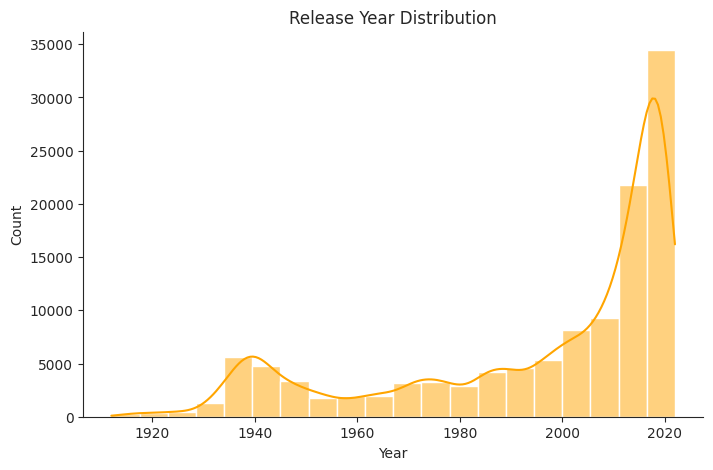

In [71]:
#Histogram of release years
plt.figure(figsize=(8,5))
sns.histplot(data = data, x = 'release_year', bins = 20, color = 'orange', kde = True)
plt.title("Release Year Distribution")
plt.xlabel("Year"); plt.ylabel("Count")
clean_plot(); plt.show()

**Insights**
- The histogram shows the distribution of movies and TV shows across different release years.
- A large number of content on Amazon Prime has been released in the last decade and the distribution is skewed towards left.  
- There is an overall increasing trend in the number of movies or TV shows released over the years, suggesting that Amazon Prime Video's content library has been expanding.

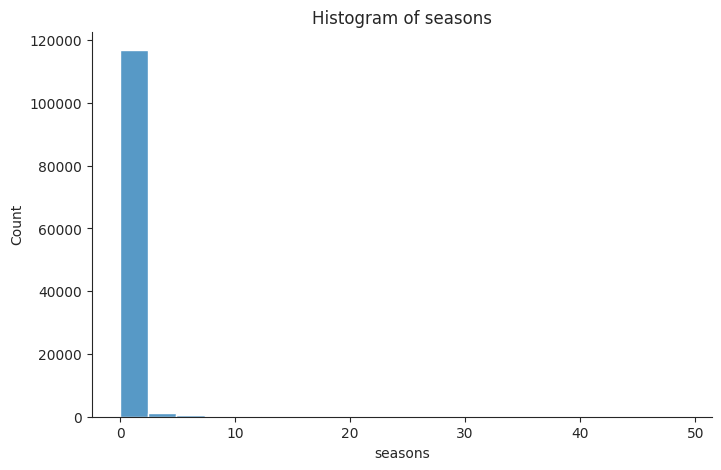

In [79]:
#Histogram of Seasons
plt.figure(figsize = (8,5))
sns.histplot(data = data, x = 'seasons', bins = 20)
plt.title('Histogram of seasons')
clean_plot()
plt.show()

**Insights**

- The histogram shows peak at 1 as seasons are only applicable to TV shows, not Movies.

- Most of the TV series on Amazon Prime have 1-3 seasons, conveying that many TV shows don't continue for more number of seasons.


#### Countplot

Displays the frequency of each category in a categorical variable

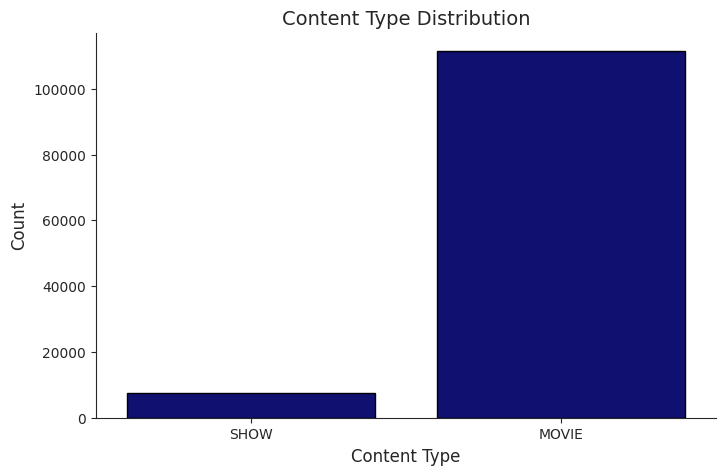

In [61]:
# Countplot of content type
plt.figure(figsize=(8,5))
sns.countplot(x='type', color='navy', edgecolor = 'black', data=data)
plt.title("Content Type Distribution", fontsize=14)
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
clean_plot()
plt.show()


**Insights**
- The bar for "MOVIE" is significantly higher than the bar for "SHOW", indicating that movies dominate the platform.
- This could be because viewers prefer movies over shows and this means that content creators can produce and release movies on this platform as movies dominate.

#### Bar chart

Compares counts or values across categories.

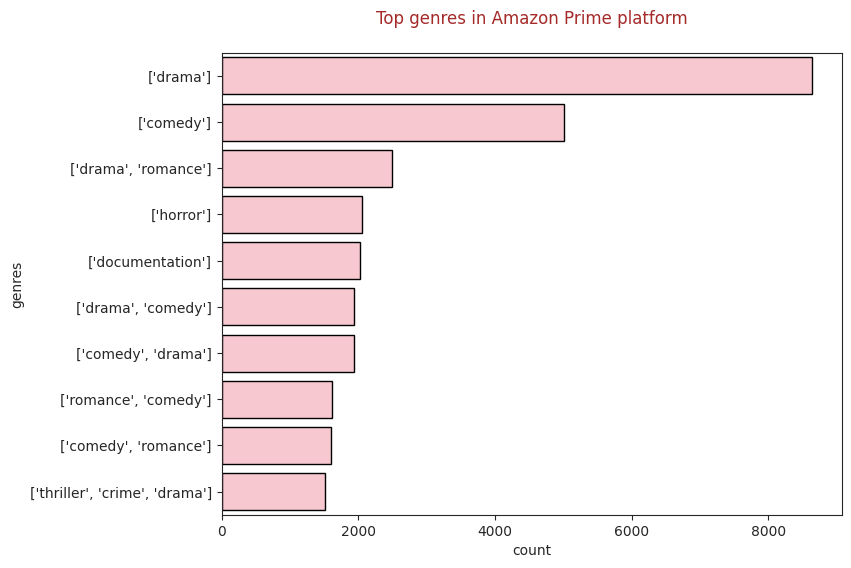

In [64]:
#Bar chart for top genres
genre_counts = data['genres'].value_counts()
k = genre_counts[genre_counts>1500]
k

plt.figure(figsize = (8,6))
sns.barplot(y = k.index, x = k.values, color = 'pink', edgecolor = 'black', orient='h')
plt.title('Top genres in Amazon Prime platform\n', color = 'brown')
plt.xlabel('count')
plt.show()

**Insights**

- The genres "drama" and "comedy" are the most common on Amazon prime.

- There are a great variety of genres available on the platform, indicating that Amazon prime offers content with diverse taste and preferences.

- The graph reflects viewers preferences and can be useful for recommending content to the viewers.

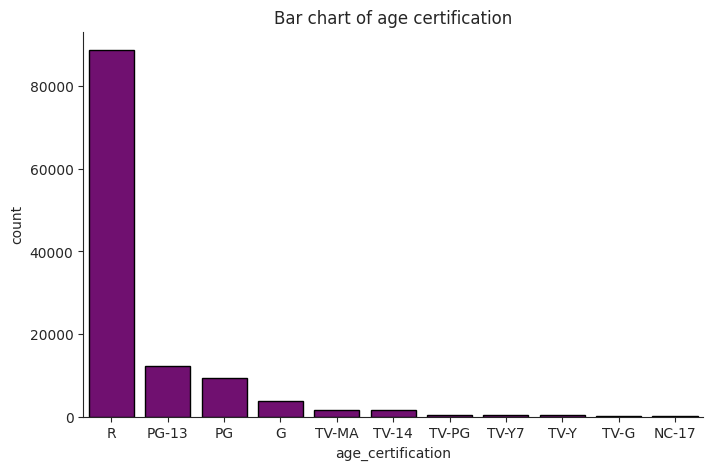

In [75]:
#Bar chart of age certification
p = data.age_certification.value_counts()
p
plt.figure(figsize = (8,5))
sns.barplot(x = p.index, y = p.values, color= 'purple', edgecolor = 'black')
plt.title('Bar chart of age certification')
plt.ylabel('count')
clean_plot()
plt.show()

**Insights**
- There are highest number of movies with 'R' certification, meaning person under 17 requires parent/adult supervision to watch the content.
- PG-13 rated Movies or TV shows are at 2nd position and may contain material that are inappropriate for children typically under the age of 13.
- 'R' rated movies dominate the platform and have higher response from audience.

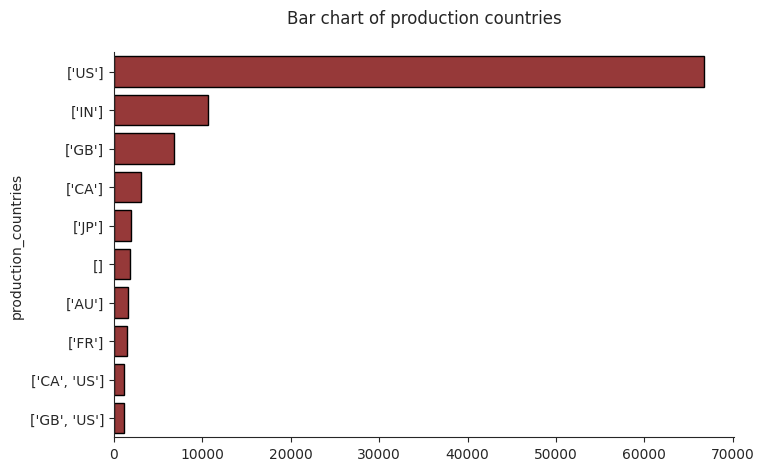

In [76]:
#Bar chart of production countries
prod_countries = data['production_countries'].value_counts()
country = prod_countries[prod_countries >1000]
country
plt.figure(figsize=(8,5))
sns.barplot(x = country.values, y = country.index, orient='h', color = 'brown', edgecolor = 'black')
plt.title('Bar chart of production countries\n')
clean_plot()
plt.show()

**Insights**

- The United States has the highest number of productions, indicating that a large portion of Amazon Prime's content is from the US.

- India and United kingdom(GB) are the next major contributors to the content library, indicating their significant presence in film and television production.

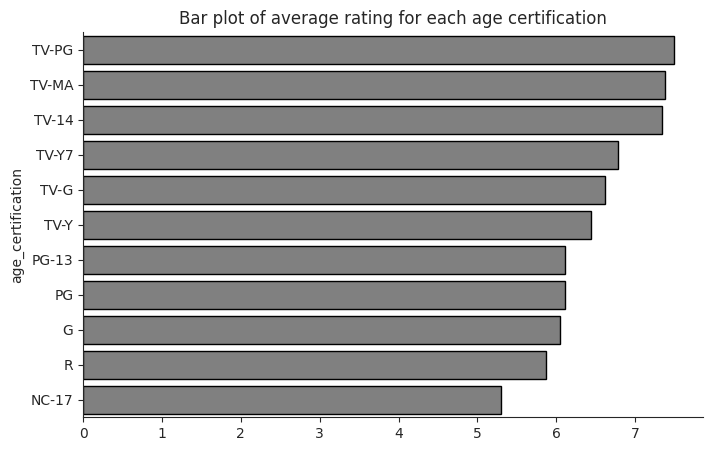

In [85]:
#Bar chart of average rating for each age certification
certification = data.groupby('age_certification')['imdb_score'].mean().sort_values(ascending = False)
plt.figure(figsize = (8,5))
sns.barplot(x = certification.values, y = certification.index, edgecolor = 'black',color = 'grey')
plt.title('Bar plot of average rating for each age certification')
clean_plot()
plt.show()

**Insights**

- Age certifications such as 'TV-PG' and 'TV-MA' tend to have slightly higher average IMDb ratings. This suggests that content targeted toward older audiences may receive higher ratings, possibly due to more complex storytelling and broader audience engagement.

- The bar plot highlights differences in average ratings across age certifications. However, this does not necessarily imply that content for younger audiences is of lower quality, as ratings can vary based on target audience preferences and viewing behavior.

#### Boxplot
Shows spread and outliers in runtime.

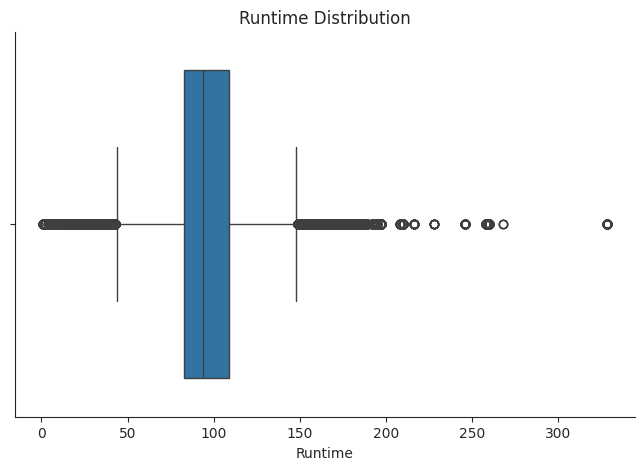

In [67]:
#Boxplot of runtime
plt.figure(figsize=(8,5))
sns.boxplot(x=data['runtime'])
plt.title("Runtime Distribution")
plt.xlabel("Runtime")
clean_plot()
plt.show()

**Insight**

- Box plot of runtime illustrates the distribution, typical runtime, spread, and outliers in the runtime data of movies and TV shows on Amazon Prime.

- The horizontal line inside the box represents the median runtime, which is around 90 minutes.

- Points plotted outside the whiskers are considered outliers. These movies or TV shows have shorter or longer runtimes compared to majority of the content.

#### Pie chart
Shows proportion of content types.

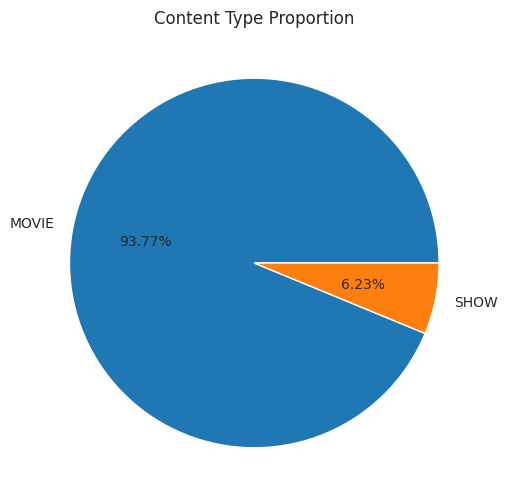

In [69]:
# Pie chart of content share
plt.figure(figsize=(6,6))
data['type'].value_counts().plot(kind='pie', autopct='%0.2f%%')
plt.title("Content Type Proportion")
plt.ylabel("")
plt.show()

**Insights**

- 93.77% of content are 'Movies', meaning that Amazon Prime mainly focuses on offering a vast collection of movies to its viewers.

- Amazon Prime caters to viewers who enjoy watching Movies more than TV series.



##**Bivariate Analysis**

####Scatterplot

 Scatter plot uses dots to represent the values of two numerical variables. Scatter plots are used to observe relationships between variables.

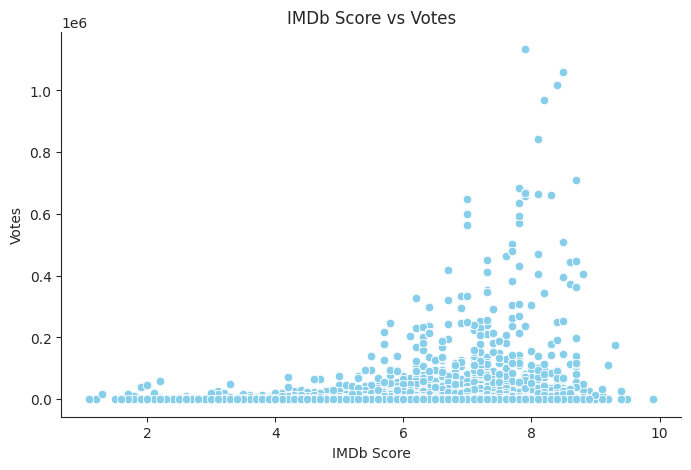

In [86]:
# Scatterplot between IMDb Score vs Votes
plt.figure(figsize=(8,5))
sns.scatterplot(x='imdb_score', y='imdb_votes', data=data, color = 'skyblue')
plt.title("IMDb Score vs Votes")
plt.xlabel("IMDb Score"); plt.ylabel("Votes")
clean_plot(); plt.show()

**Insights**
- Positive Correlation: The scatter plot shows a positive correlation between imdb_votes and imdb_score. Positive correlation suggests that titles with more votes are popular and receive higher ratings.

#### Boxplot

Compares ratings across content types.

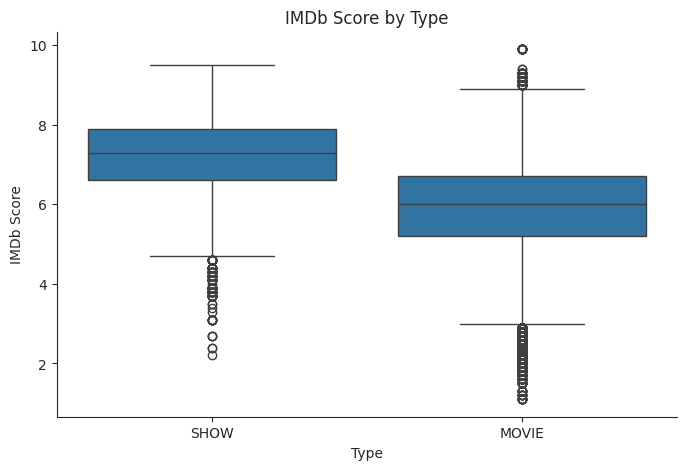

In [87]:
# Boxplot type vs imdb score
plt.figure(figsize=(8,5))
sns.boxplot(x='type', y='imdb_score', data=data)
plt.title("IMDb Score by Type")
plt.xlabel("Type"); plt.ylabel("IMDb Score")
clean_plot(); plt.show()

**Insights**

- Although movies dominate the platform in terms of quantity, the boxplot shows that TV shows have a slightly higher median IMDb score.
- This suggests that while fewer in number, TV shows tend to be better rated on average, possibly due to stronger storytelling, longer audience engagement, or more selective production.
- The boxplot shows that movies have outliers both below and above those of TV shows, indicating greater variability in their IMDb ratings. While some movies receive very low ratings, others achieve exceptionally high ratings, suggesting a wider range of quality compared to TV shows.

#### Bar plot
Shows average runtime by type

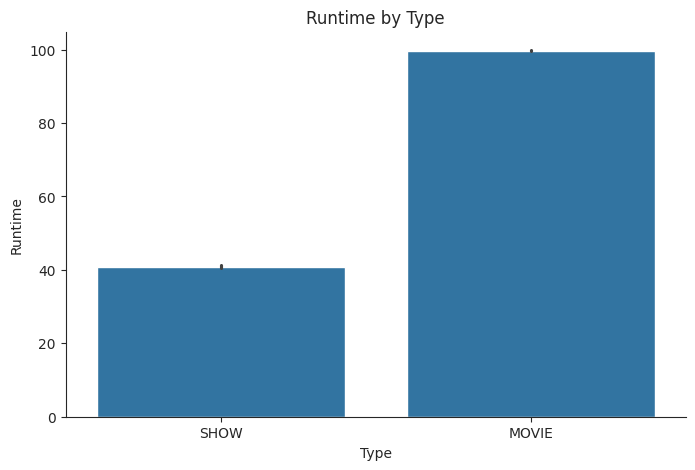

In [88]:
# Bar plot of average runtime vs type
plt.figure(figsize=(8,5))
sns.barplot(x='type', y='runtime', data=data)
plt.title("Runtime by Type")
plt.xlabel("Type"); plt.ylabel("Runtime")
clean_plot(); plt.show()

**Insights**
- The bar plot shows that movies have a significantly higher average runtime (around 100 minutes) compared to TV shows (around 40 minutes).
- This indicates that movies are typically longer, while TV shows are designed to be shorter, episodic content for easier consumption.
- Shorter TV show runtimes (40 min) support binge-watching and user retention, while longer movies (100 min) cater to immersive viewing, suggesting a balanced content strategy is essential.

#### Line Plot
Line plot shows trends over time across continuous variable.

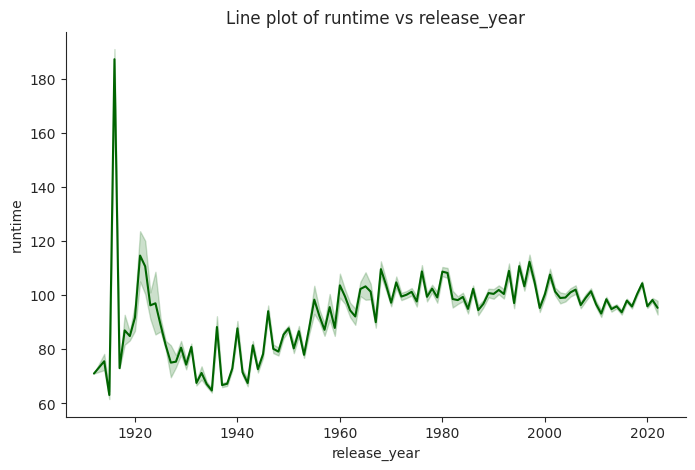

In [90]:
# Line plot of runtime vs release_year
plt.figure(figsize = (8,5))
sns.lineplot(data = data, y = 'runtime', x = 'release_year', color = 'darkgreen')
plt.title('Line plot of runtime vs release_year')
clean_plot()
plt.show()

**Insight**
- There is an overall downward trend in average runtime of movies and TV shows over the years.

- In earlier years, movies and TV shows had longer runtimes, but in recent years, the average runtime has decreased possibly because of shorter attention span of viewers and production cost.

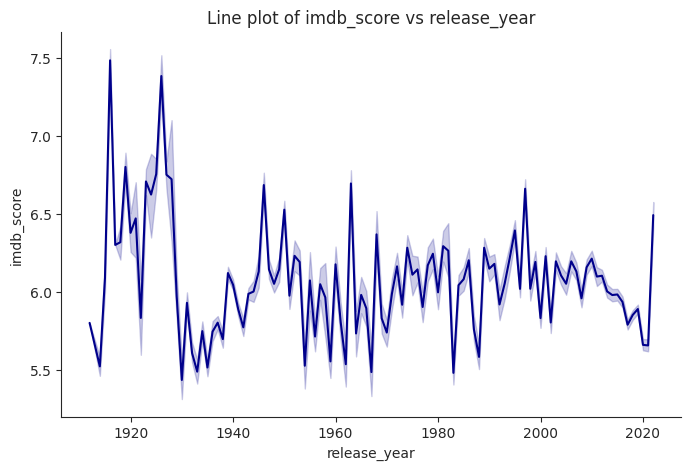

In [91]:
# Line plot of imdb_score vs release_year
plt.figure(figsize = (8,5))
sns.lineplot(data = data, y = 'imdb_score', x = 'release_year', color = 'darkblue')
plt.title('Line plot of imdb_score vs release_year')
clean_plot()
plt.show()

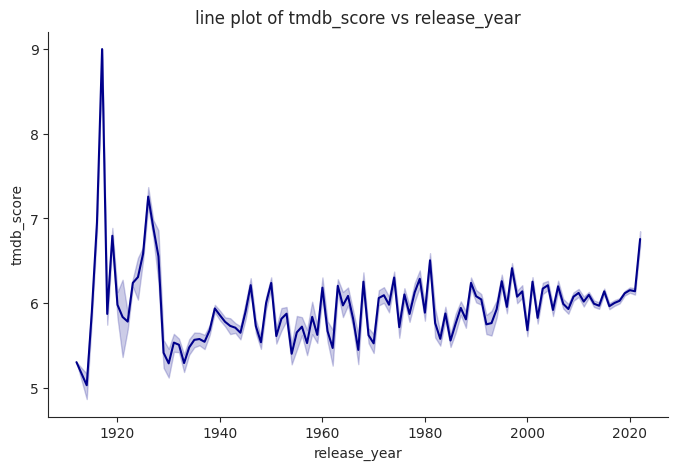

In [92]:
# Line plot of tmdb_score vs release_year
plt.figure(figsize = (8,5))
sns.lineplot(data = data, y = 'tmdb_score', x = 'release_year', color = 'darkblue')
plt.title('line plot of tmdb_score vs release_year')
clean_plot()
plt.show()

**Insights**

- There is slight downward trend in average imdb and tmdb scores over the years with some upward spikes in certain years. This suggests that older content on Amazon Prime has higher imdb rating compared to latest ones.

- Several factors could affect the observed trend, such as change in viewers taste, evolving production style and increased competition from other platforms like Netflix.

#### Violin Plot
A Violin Plot is a statistical chart that combines aspects of a box plot and a kernel density plot to visualize the distribution of a numeric variable across different categories or groups.

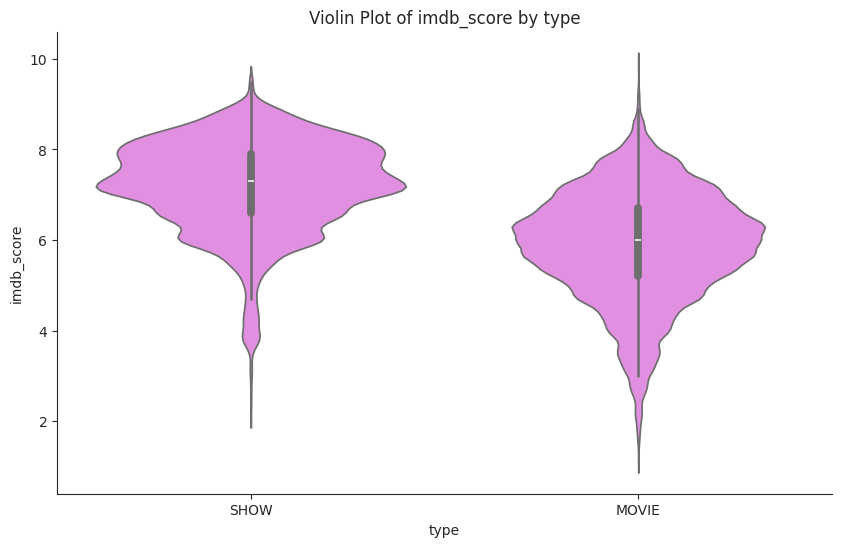

In [95]:
#Violin Plot of imdb_score by type
plt.figure(figsize=(10, 6))
sns.violinplot(x='type', y='imdb_score', data=data, color = 'violet')
plt.title('Violin Plot of imdb_score by type')
clean_plot()
plt.show()

**Insights**

- Movies: The distribution of imdb_score for movies shows higher density of scores between 6 and 7. Therefore, most movies on Amazon Prime have decent ratings with a tendency towards higher scores.

- TV Shows: The distribution of imdb_score for TV shows have higher density of scores between 7 and 8.

- The median imdb_score for Movies (indicated by the white dot inside the violin) is slightly lower than that of TV shows meaning that on average, TV shows on Amazon Prime tend to have higher ratings than Movies.

#**Multivariate Analysis**

#### Correlation Heatmap
A heatmap uses color intensities to represent the strength of relationships(correlation) between numeric variables in a dataset.

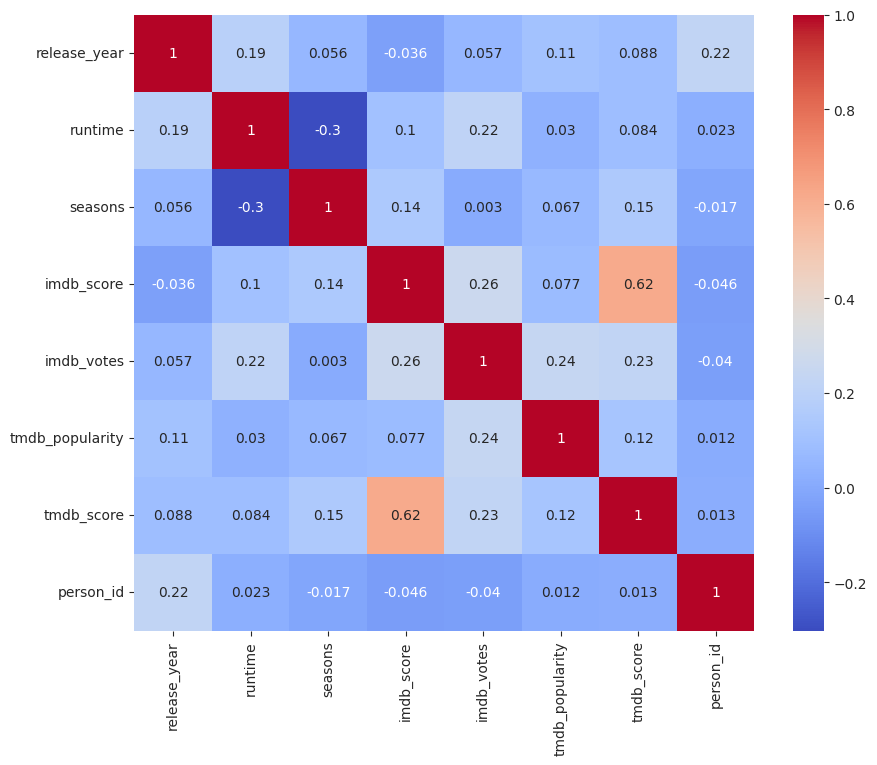

In [98]:
# Correlation Heatmap visualization code
num_col = data.select_dtypes(include = ['int64','float64'])
plt.figure(figsize = (10,8))
sns.heatmap(num_col.corr(), annot = True, cmap='coolwarm')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Pair Plot
Pair plot visualizes the pairwise relationship between variables. It includes scatter plots for relationships and histogram or density plots for individual distributions.

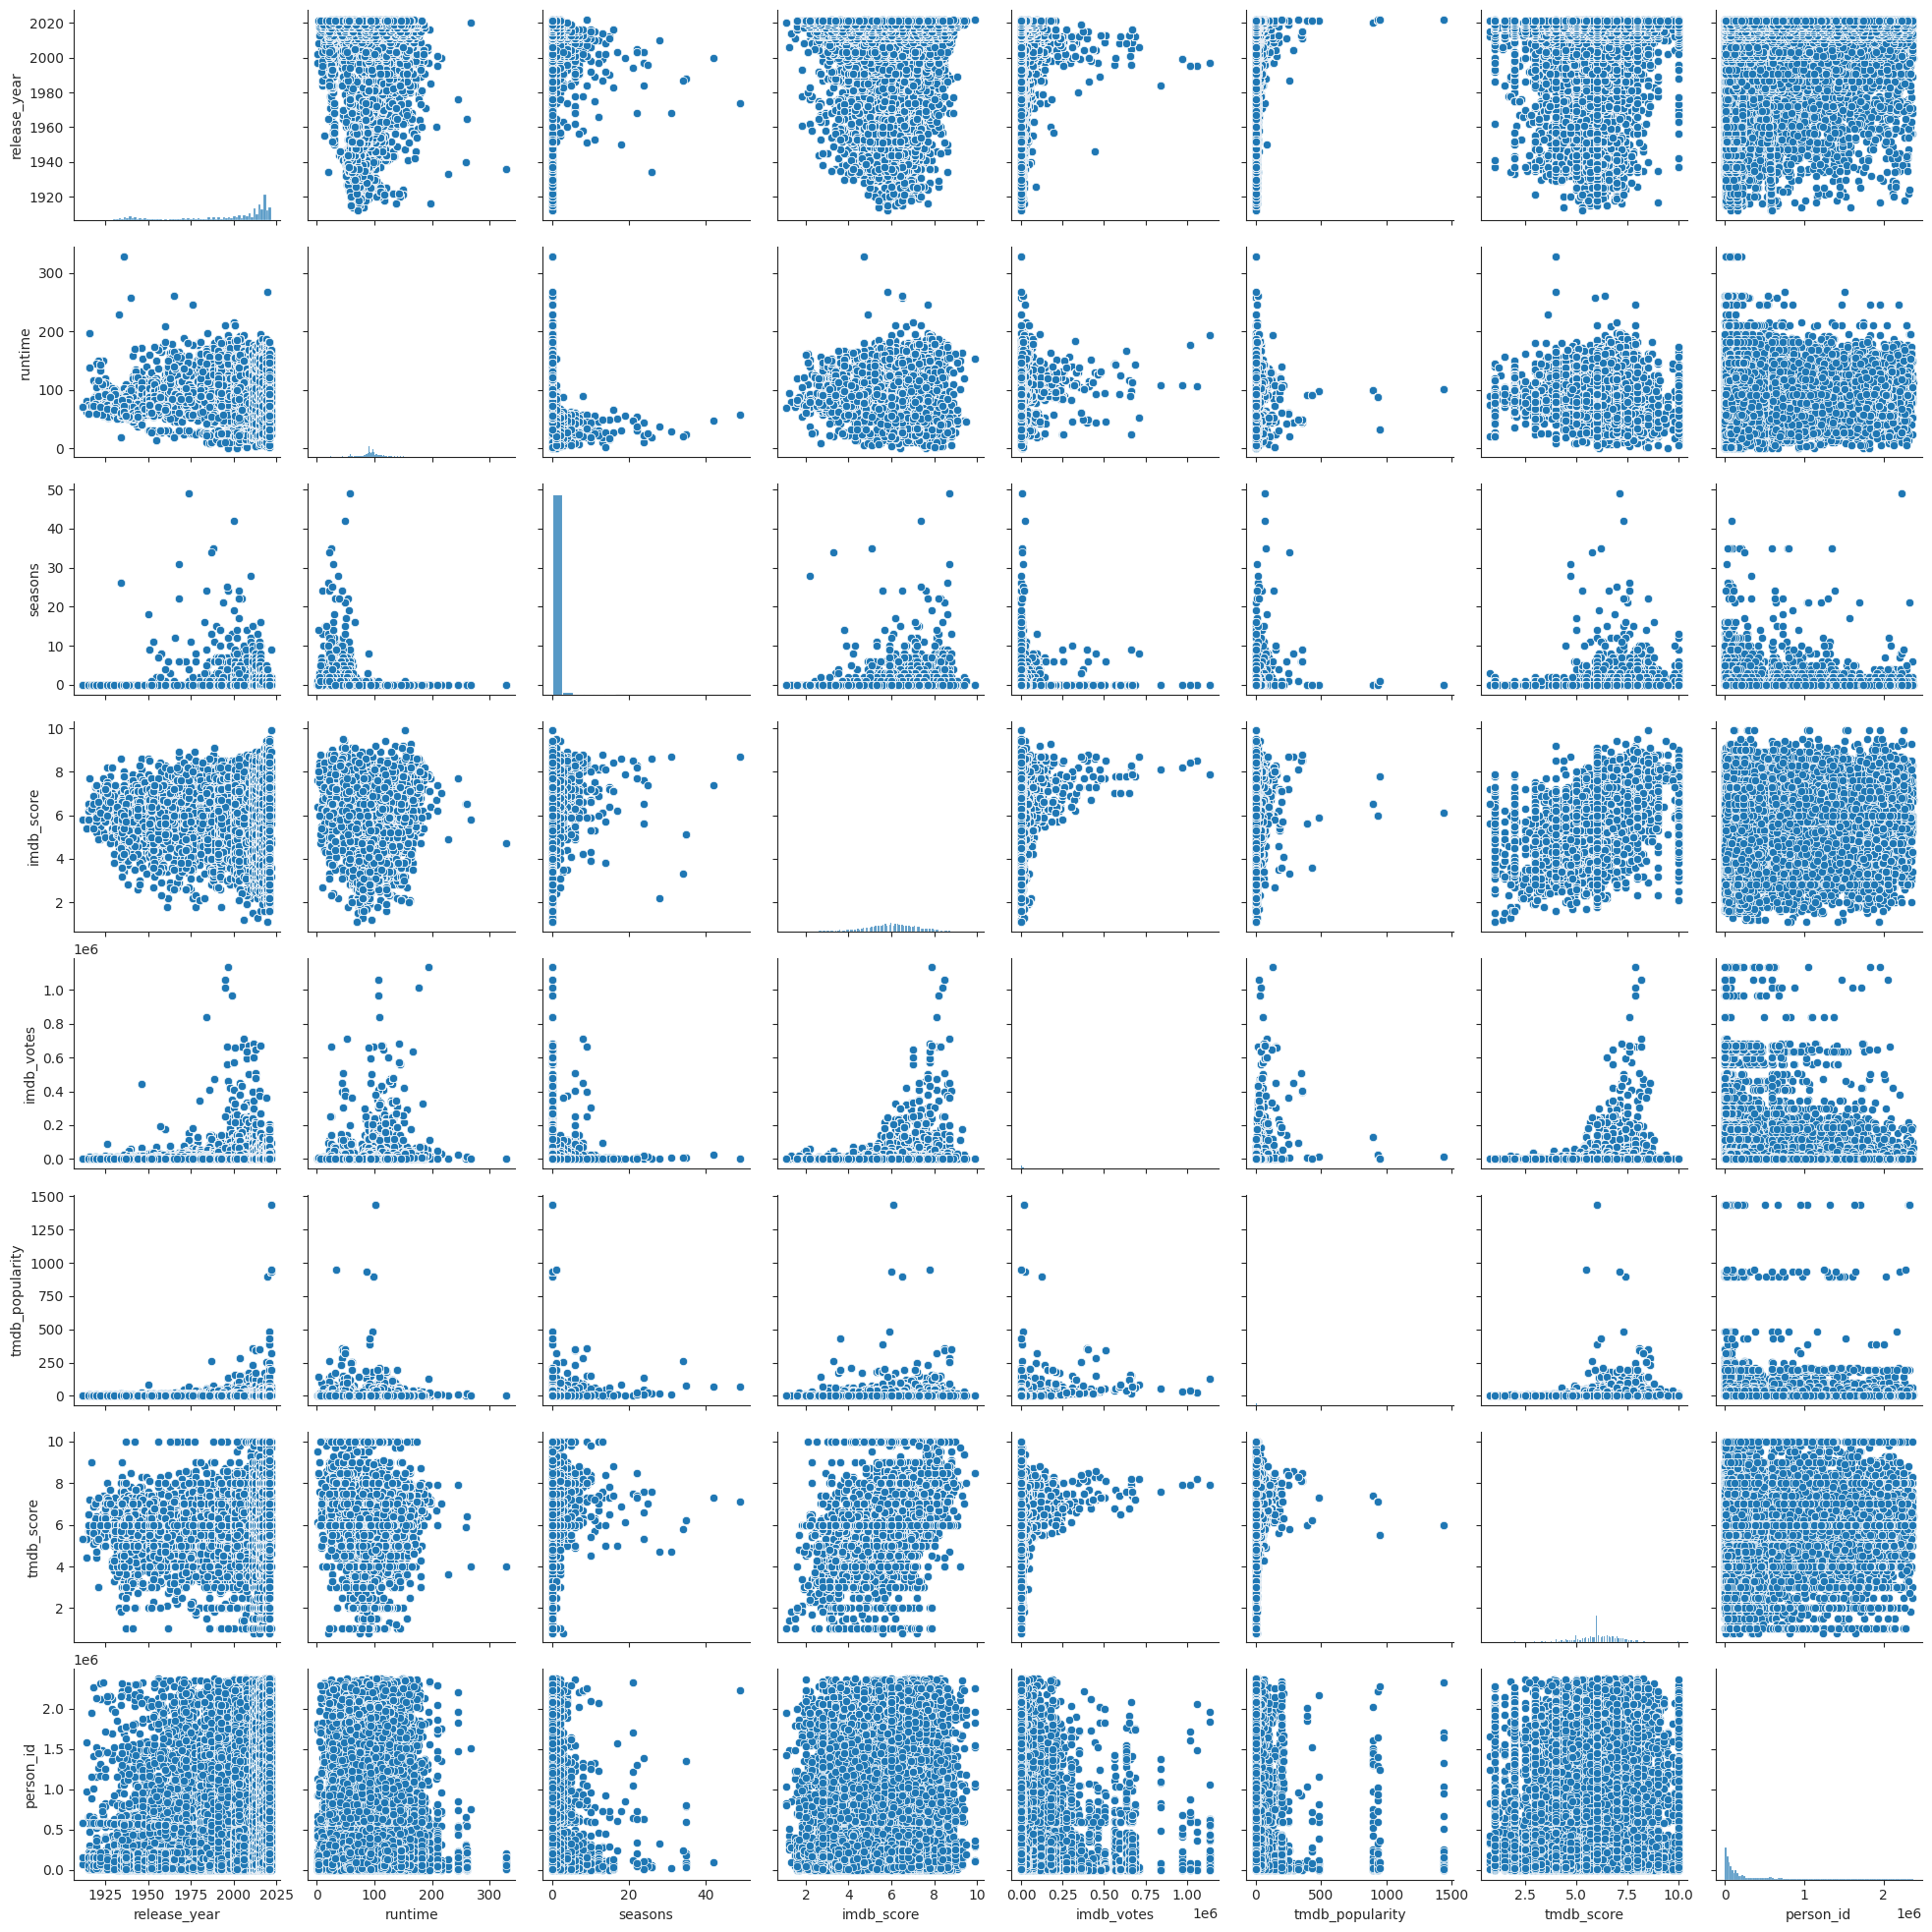

In [97]:
# Pair Plot visualization code
sns.pairplot(data)
plt.show()

## **5. Solution to Business Objective**

- **Invest More in High-Quality TV Shows:** TV shows show higher median IMDb ratings and strong audience engagement. Increasing production of high-quality series can improve user retention and binge-watching behavior.

- **Balance Content Strategy:** While movies dominate the platform, maintaining a balanced mix of movies and TV shows will help cater to both short-term and long-term viewing preferences.

- **Focus on Popular Genres:** Drama and comedy are the most preferred genres. Expanding content in these categories can attract a larger audience and increase platform engagement.

- **Leverage Mature Audience Content:** Content with higher age certifications tends to receive better ratings. Producing more mature, high-quality content may improve overall audience satisfaction.

- **Optimize Content Duration:** Shorter TV show runtimes (40 mins) support binge-watching, while longer movies (100 mins) provide immersive experiences. A mix of both can maximize user engagement.

- **Expand Regional Content:** The US, India, and the UK dominate production. Investing in more regional and diverse content can help capture global audiences.

- **Promote High-Rated Content:** Strong correlation between IMDb ratings and votes suggests that promoting highly rated content can increase visibility and viewer engagement.

- **Focus on Long-Term Engagement Trends:** Increasing number of seasons in TV shows indicates a shift toward sustained viewer interest. Developing long-running series can improve platform loyalty.

- **Improve New Content Quality:** Older content tends to have higher ratings, suggesting a need to enhance the quality of newer releases to meet audience expectations.

- **Data-Driven Content Decisions:** Continuously using data analytics to monitor viewer preferences, ratings, and trends will help optimize content strategy and business growth.

# **Conclusion**

This Exploratory Data Analysis (EDA) of the Amazon Prime Video dataset has provided valuable insights into the platform's content, trends, and user preferences.

- **Content Distribution:** Amazon Prime Video has a higher proportion of movies compared to TV shows, indicating a stronger focus on movie content.

- **Genre Insights:** Drama and comedy are the most dominant genres, reflecting popular audience preferences, while the platform still maintains a diverse range of genres.

- **Content Trends:** Over time, movie runtimes have slightly decreased, whereas TV shows have increased in the number of seasons, suggesting a shift toward long-term viewer engagement.

- **Ratings Analysis:** Older titles generally have higher IMDb and TMDb ratings compared to newer releases, possibly due to nostalgia or changing audience expectations.

- **Geographical Contribution:** The United States contributes the most content, followed by India and the United Kingdom, highlighting their importance in content production.

- **Overall Insight:** The analysis reveals clear patterns in content strategy, audience preferences, and platform evolution, which can help in making data-driven decisions.

- **Future Scope:** Further analysis by genre, region, or content type can provide deeper insights for improving content strategy and user engagement.
